# Region boundaries on the ECCO LLC90 lat-lon-cap grid

This example applies `regionate` to the **ECCOv4r4 native lat-lon-cap (LLC90)** grid — a
genuinely *multi-tile* ocean grid whose 13 tiles are connected by an `xgcm`
`face_connections` topology (with rotated seams and an Arctic "cap"). It traces the
**Atlantic basin** mask into a single grid-conforming boundary that spans many tiles, and
shows that the boundary converts to staggered velocity `(u, v)` faces — the property that
makes volume/heat/salt budgets over the region consistent with the fluxes through its
boundary (the discrete flux-divergence theorem).

The grid is loaded natively (MITgcm 'left'-staggered vorticity points), which
`sectionate` now supports directly; no conversion to a symmetric grid is needed.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

from load_example_ECCO_grid import load_ECCO_LLC90_grid, atlantic_basin_mask
from regionate import MaskRegions
import sectionate as sec

grid = load_ECCO_LLC90_grid()
grid

<xgcm.Grid>
X Axis (not periodic, boundary='fill'):
  * center   i --> left
  * left     i_g --> center
Y Axis (not periodic, boundary='fill'):
  * center   j --> left
  * left     j_g --> center

## The LLC90 grid

13 tiles, tracer-center coordinates `geolon`/`geolat`, and cell-corner (vorticity)
coordinates `geolon_c`/`geolat_c` on the native 'left' position. `Depth` gives the
land/ocean geometry. The Arctic "cap" is tile 6.

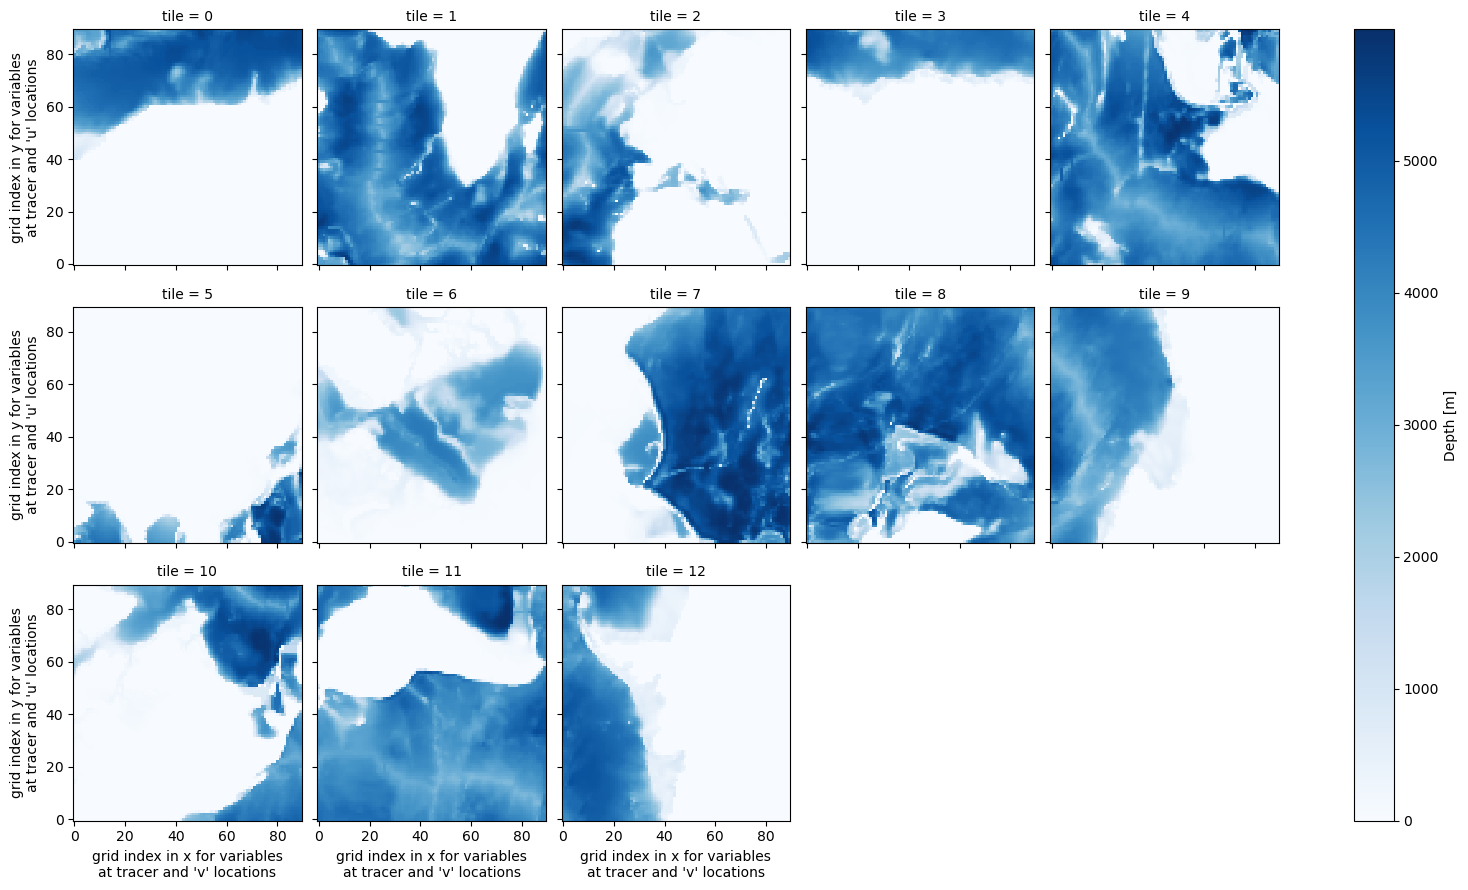

In [2]:
grid._ds["Depth"].plot(col="tile", col_wrap=5, cmap="Blues",
                       cbar_kwargs={"label": "Depth [m]"})
plt.show()

## The Atlantic basin mask

We use the published **Natural Earth ocean basins** (North + South Atlantic Ocean) via
`regionmask`, intersected with ocean points. Using a published basin polygon — rather
than a longitude/latitude box — keeps the mask geographically correct: it follows the
coastlines and excludes the Pacific.

In [3]:
atlantic = atlantic_basin_mask(grid)
lon, lat = grid._ds["geolon"], grid._ds["geolat"]
tiles_in_mask = sorted(set(np.where(atlantic.values.any(axis=(1, 2)))[0].tolist()))
print(f"Atlantic ocean cells: {int(atlantic.sum())}  spanning tiles: {tiles_in_mask}")

Atlantic ocean cells: 10149  spanning tiles: [0, 1, 2, 10, 11, 12]


## Trace the basin boundary

`MaskRegions` traces the mask. The basin perimeter is the largest loop (the smaller loops
are islands / interior coastline). Its per-corner face index `f_c` spans every tile the
Atlantic touches — the boundary is stitched across the rotated tile seams and the cap.

In [4]:
regions = MaskRegions(atlantic, grid).region_dict
basin = max(regions.values(), key=lambda r: len(r.lons_c))
faces = np.asarray(basin.f_c)[:-1]   # f_c is a closed loop; align with the open lon/lat
print(f"boundary loops (basin + islands): {len(regions)}")
print(f"basin perimeter: {len(basin.lons_c)} corners, spanning tiles {sorted(set(faces.tolist()))}")
print(f"seam crossings along the perimeter (face changes): "
      f"{int((np.asarray(basin.f_c)[:-1] != np.asarray(basin.f_c)[1:]).sum())}")

boundary loops (basin + islands): 12
basin perimeter: 720 corners, spanning tiles [0, 1, 2, 10, 11, 12]
seam crossings along the perimeter (face changes): 8


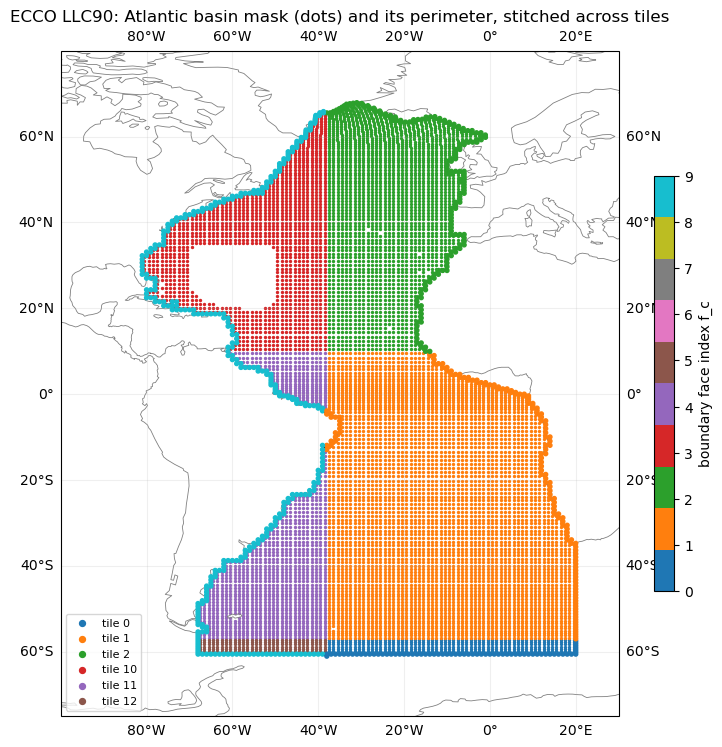

In [5]:
fig = plt.figure(figsize=(9, 9))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-100, 30, -75, 80], crs=ccrs.PlateCarree())
ax.coastlines(color="0.5", linewidth=0.6)
ax.gridlines(draw_labels=True, alpha=0.2)
for t in tiles_in_mask:
    mt = atlantic.isel(tile=t).values
    ax.scatter(lon.isel(tile=t).values[mt], lat.isel(tile=t).values[mt], s=2, label=f"tile {t}")
ax.plot(basin.lons_c, basin.lats_c, "-", color="k", lw=0.9, zorder=4)
sc = ax.scatter(basin.lons_c, basin.lats_c, c=faces, cmap="tab10", vmin=0, vmax=9, s=8, zorder=5)
plt.colorbar(sc, ax=ax, label="boundary face index f_c", shrink=0.6)
ax.legend(loc="lower left", fontsize=8, markerscale=3)
ax.set_title("ECCO LLC90: Atlantic basin mask (dots) and its perimeter, stitched across tiles")
plt.show()

## Grid-consistent velocity faces (flux-divergence consistency)

The whole point of an xgcm-grid-consistent boundary is that it can be expressed as a
sequence of staggered velocity `(u, v)` faces. `sectionate.uvindices_from_qindices` turns
the corner loop into those faces; integrating the model's volume/heat/salt fluxes through
them then exactly balances the storage change inside the masked region. This step
requires the boundary to be grid-adjacent at every corner — including across the rotated
seams and the Arctic cap.

In [6]:
uv = sec.uvindices_from_qindices(grid, basin.i_c, basin.j_c, f_c=basin.f_c)
nU = int((uv["var"] == "U").sum()); nV = int((uv["var"] == "V").sum())
print(f"basin boundary -> {len(uv['var'])} velocity faces ({nU} U-faces, {nV} V-faces)")
print(f"faces lie on tiles: {sorted(set(uv['face'].tolist()))}")
# A budget over the region would sum the model's transports through exactly these faces.

basin boundary -> 720 velocity faces (368 U-faces, 352 V-faces)
faces lie on tiles: [0, 1, 2, 10, 11, 12]


## Notes

- regionate traces the boundary face-by-face with `contourpy`, removes the internal
  tile-seam faces (where the region is in-mask on both sides), and stitches the remaining
  open arcs across seams using the grid topology (cell adjacency) — no reliance on
  coordinate coincidence, so rotated/reversed seams and the cap are handled uniformly.
- The native 'left' MITgcm/ECCO staggering is consumed directly via
  `sectionate.gridutils` (`corner_position`/`corner_offset`); the same code path also
  handles symmetric ('outer') and 'right' grids.